In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import qnas_config as cfg
import torch
from util import plot_training_history

In [3]:
phase = 'evolution'
experiment_path = 'my_exp_config2'
config_file = 'config_files/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict

params = config.train_spec

net_list = ['conv_3_1_256','no_op', 'conv_3_1_128', 'no_op','no_op','no_op',
            'conv_3_1_64','conv_3_1_64','no_op','conv_3_1_256','conv_3_1_256',
            'max_pool_2_2', 'conv_3_1_128', 'no_op','no_op','no_op','no_op','no_op',
            'max_pool_2_2', 'conv_3_1_128']

In [4]:
# create a list with all available cuda devices
device_list = [f'cuda:{i}' for i in range(torch.cuda.device_count())]
device_list

['cuda:0', 'cuda:1', 'cuda:2']

In [5]:
params['device'] = device_list[1]
params['device']

'cuda:1'

In [6]:
from cnn.train import fitness_calculation
from cnn.input import cifar10_info

data = {
    "num_classes": 10,
}
params['limit_data'] = True

# AdamW

In [7]:
results_dict_2 = fitness_calculation(id_num="job_1", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
results_dict_2["best_accuracy"]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training Fitness Scheme:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch [5/100] - Training loss: 2.9544215003649392
Epoch [10/100] - Training loss: 2.5311121543248496
Epoch [15/100] - Training loss: 2.147253202067481
Epoch [20/100] - Training loss: 2.14157681994968
Epoch [25/100] - Training loss: 1.9270565973387823
Epoch [30/100] - Training loss: 1.8008744319279988
Epoch [35/100] - Training loss: 1.8727078239123027
Epoch [40/100] - Training loss: 1.6968066063192155
Epoch [45/100] - Training loss: 1.5846903257899814
Epoch [50/100] - Training loss: 1.558086140288247
Epoch [55/100] - Training loss: 1.5053036279148526
Epoch [60/100] - Training loss: 1.392875115076701
Epoch [65/100] - Training loss: 1.318165832095676
Epoch [70/100] - Training loss: 1.3028592533535428
Epoch [75/100] - Training loss: 1.3025412129031286
Epoch [80/100] - Training loss: 1.3417584929201338
Epoch [85/100] - Training loss: 1.2335890134175618
Epoch [91/100] - Training loss: 1.2025685012340546 - Validation loss: 2.9283840656280518 - Validation accuracy: 63.285714285714285%
Epoch [9

70.14285714285714

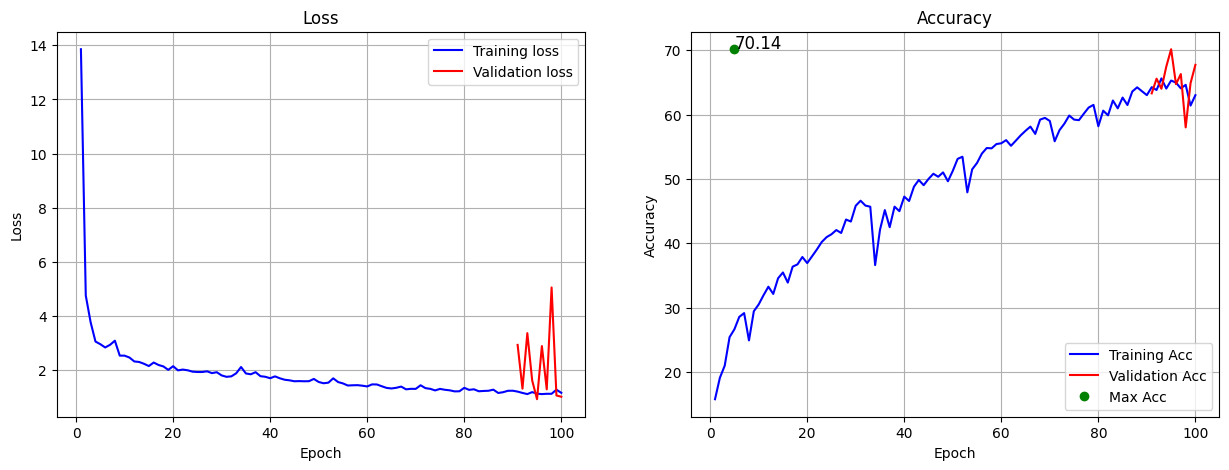

In [8]:
plot_training_history(results_dict_2, params)

# Adam

In [9]:
params['optimizer'] = 'Adam'

In [10]:
results_dict_3 = fitness_calculation(id_num="job_2", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
results_dict_3["best_accuracy"]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training Fitness Scheme:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch [5/100] - Training loss: 2.8013686558295943
Epoch [10/100] - Training loss: 2.9061559808665307
Epoch [15/100] - Training loss: 2.4703647679296035
Epoch [20/100] - Training loss: 2.382629341092603
Epoch [25/100] - Training loss: 2.0279895807134696
Epoch [30/100] - Training loss: 2.1663174958064637
Epoch [35/100] - Training loss: 2.0981221199035645
Epoch [40/100] - Training loss: 2.1260687318341485
Epoch [45/100] - Training loss: 2.005110633784327
Epoch [50/100] - Training loss: 1.8125454351819794
Epoch [55/100] - Training loss: 1.808989903022503
Epoch [60/100] - Training loss: 1.6827555442678517
Epoch [65/100] - Training loss: 1.6791856288909912
Epoch [70/100] - Training loss: 1.760474965490144
Epoch [75/100] - Training loss: 1.7065333867895192
Epoch [80/100] - Training loss: 2.038342866404303
Epoch [85/100] - Training loss: 1.6902987751467475
Epoch [91/100] - Training loss: 1.9064202349761437 - Validation loss: 1.6769284009933472 - Validation accuracy: 61.3%
Epoch [92/100] - Trai

64.1

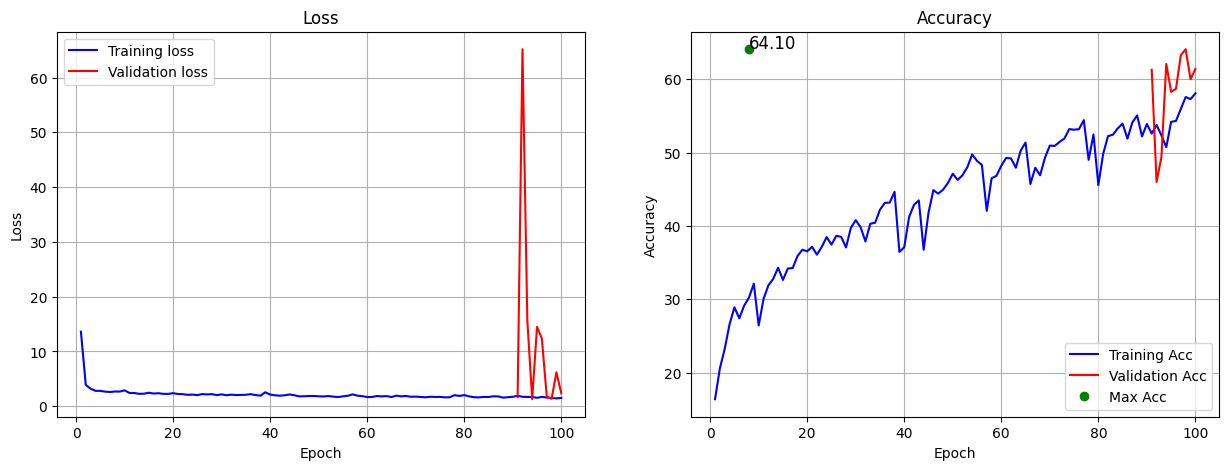

In [11]:
plot_training_history(results_dict_3, params)